<a href="https://colab.research.google.com/github/RidhiSood22/neural-network-with-learnable-gates/blob/main/neural_network_with_learnable_gates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s]


Train size: 50000
Test size: 10000


In [3]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features)*0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features)-3)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores*3)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

In [4]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [5]:
def sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += gates.mean()
    return loss

In [6]:
def train_model(lambda_val, epochs=10):
    model = PrunableNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            ce_loss = F.cross_entropy(outputs, labels)
            sp_loss = sparsity_loss(model)

            loss = ce_loss + lambda_val * sp_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

    return model

In [7]:
def evaluate(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [8]:
def calculate_sparsity(model, threshold=1e-2):
    total, zero = 0, 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores*2)

            total += gates.numel()
            zero += (gates < threshold).sum().item()

    return 100 * zero / total

In [9]:
lambdas = [1e-5, 1e-4, 1e-3]
results = []

best_model = None
best_acc = 0

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = train_model(lam)
    acc = evaluate(model)
    sparsity = calculate_sparsity(model)

    results.append((lam, acc, sparsity))

    if acc > best_acc:
        best_acc = acc
        best_model = model

    print(f"Accuracy: {acc:.2f}%, Sparsity: {sparsity:.2f}%")


Training with lambda = 1e-05
Epoch 1, Loss: 1626.11
Epoch 2, Loss: 1348.95
Epoch 3, Loss: 1250.63
Epoch 4, Loss: 1199.75
Epoch 5, Loss: 1163.38
Epoch 6, Loss: 1133.50
Epoch 7, Loss: 1104.83
Epoch 8, Loss: 1079.38
Epoch 9, Loss: 1054.88
Epoch 10, Loss: 1032.33
Accuracy: 50.54%, Sparsity: 71.39%

Training with lambda = 0.0001
Epoch 1, Loss: 1617.28
Epoch 2, Loss: 1345.49
Epoch 3, Loss: 1253.41
Epoch 4, Loss: 1201.26
Epoch 5, Loss: 1164.70
Epoch 6, Loss: 1133.52
Epoch 7, Loss: 1106.22
Epoch 8, Loss: 1081.84
Epoch 9, Loss: 1058.44
Epoch 10, Loss: 1036.62
Accuracy: 50.51%, Sparsity: 71.56%

Training with lambda = 0.001
Epoch 1, Loss: 1618.83
Epoch 2, Loss: 1348.81
Epoch 3, Loss: 1257.50
Epoch 4, Loss: 1204.13
Epoch 5, Loss: 1166.37
Epoch 6, Loss: 1136.48
Epoch 7, Loss: 1109.87
Epoch 8, Loss: 1085.69
Epoch 9, Loss: 1062.36
Epoch 10, Loss: 1040.31
Accuracy: 50.73%, Sparsity: 72.29%


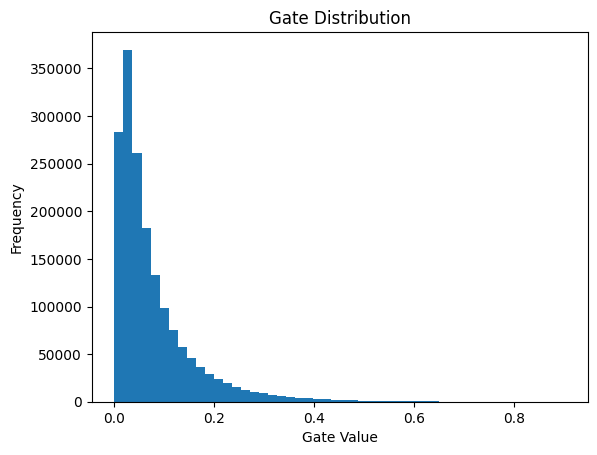

In [11]:
all_gates = []

for module in best_model.modules():
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
        all_gates.extend(gates.flatten())

plt.hist(all_gates, bins=50)
plt.title("Gate Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()


In [12]:
print("\nFinal Results:")
for r in results:
    print(f"Lambda={r[0]}, Accuracy={r[1]:.2f}%, Sparsity={r[2]:.2f}%")


Final Results:
Lambda=1e-05, Accuracy=50.54%, Sparsity=71.39%
Lambda=0.0001, Accuracy=50.51%, Sparsity=71.56%
Lambda=0.001, Accuracy=50.73%, Sparsity=72.29%
